### Load Data

In [89]:
from sklearn.neighbors import KernelDensity
import numpy as np
from Bio import SeqIO
import pandas as pd
import csv

aa_properties_ref = {}
properties_list = []
with open('properties/15_aa_properties.csv', 'r') as aa_properties:
    reader = csv.DictReader(aa_properties, delimiter=',')
    for row in reader:
        aa_properties_ref[row["AA_ABREV"]] = {}
        for aa_property in row:
            if aa_property != "AA_ABREV":
                aa_properties_ref[row["AA_ABREV"]][aa_property] = row[aa_property]
                if not aa_property in properties_list:
                    properties_list.append(aa_property)
with open('fasta/c_start_seq_ol.fasta', 'r') as seq_ol:
    aligned_seqs = list(SeqIO.parse(seq_ol, 'fasta'))

aligned_seqs_dict = {}
for seq in aligned_seqs:
    aligned_seqs_dict[seq.id] = str(seq.seq)

binned_data_seqs = {'id':[], 'category':[], 'aligned_seq':[], 'misclassified':[]}

with open('csv/condensation_starter_train_misclassified.csv') as binned_data:
    reader = csv.reader(binned_data, delimiter=',')
    for row in reader:
        if row[1] in ['AR', 'SCFA', 'MCFA', 'LCFA', 'FA']:
            binned_data_seqs['id'].append(row[5])
            binned_data_seqs['category'].append(row[1])
            binned_data_seqs['misclassified'].append(row[2])
            binned_data_seqs['aligned_seq'].append(aligned_seqs_dict[row[5]])

df2 = pd.DataFrame(binned_data_seqs)
df2['category_simple'] = df2['category'].apply(lambda x:x[-2:])
#analysis_df = df2.copy()
#for pos in range(0,979):
#    analysis_df[str(pos)] = df2['aligned_seq'].apply(lambda x:x[pos])
#    analysis_df[str(pos)] = df2['aligned_seq'].apply(lambda x:aa_properties_ref[x[pos]]['CHOP780203'])
#    analysis_df = analysis_df.copy()

### Plot Visualization

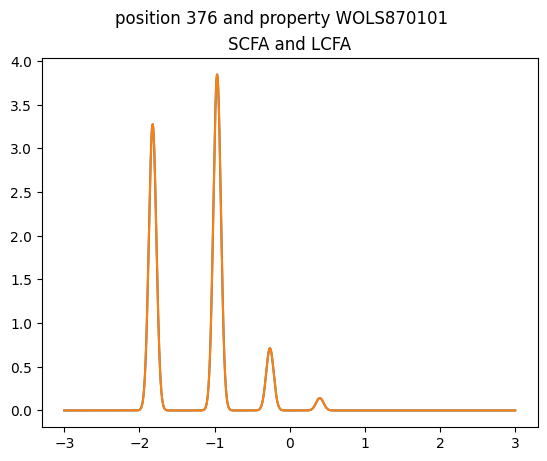

In [88]:
'''
WOLS870101
WOLS870102
WOLS870103
FAUJ880109
GRAR740102
RADA880108
ZIMJ680103
TSAJ990101
CHOP780201
CHOP780202
CHOP780203
ZIMJ680104
NEU1
NEU2
NEU3
'''

POSITION = 555
PROPERTY = 'WOLS870103'

CATEGORY_1 = 'SCFA'
CATEGORY_2 = 'LCFA'


df2 = pd.DataFrame(binned_data_seqs)
df2['category_simple'] = df2['category'].apply(lambda x:x[-2:])
analysis_df = df2.copy()
for pos in range(0,979):
    analysis_df[str(pos)] = df2['aligned_seq'].apply(lambda x:x[pos])
    analysis_df[str(pos)] = df2['aligned_seq'].apply(lambda x:aa_properties_ref[x[pos]][PROPERTY])
    analysis_df = analysis_df.copy()

#analysis_df_ar = analysis_df[analysis_df['category_simple'] == 'AR']
#analysis_df_fa = analysis_df[analysis_df['category_simple'] == 'FA']

analysis_df_ar = analysis_df[analysis_df['category'] == CATEGORY_1]
analysis_df_fa = analysis_df[analysis_df['category'] == CATEGORY_2]

kdear = KernelDensity(kernel='gaussian', bandwidth=0.05).fit(np.array(analysis_df_ar[str(POSITION)]).reshape(-1,1))
kdefa = KernelDensity(kernel='gaussian', bandwidth=0.05).fit(np.array(analysis_df_fa[str(POSITION)]).reshape(-1,1))

arshape = kdear.score_samples(np.linspace(-3,3,6000).reshape(-1,1))
fashape = kdefa.score_samples(np.linspace(-3,3,6000).reshape(-1,1))

exp_fashape = []
for i in fashape:
    exp_fashape.append(np.exp(i))

exp_arshape = []
for i in arshape:
    exp_arshape.append(np.exp(i))

# misclassified plots

analysis_df_mar = analysis_df[(analysis_df['category'] == CATEGORY_1) & (analysis_df['misclassified'] == 'T')]
analysis_df_mfa = analysis_df[(analysis_df['category'] == CATEGORY_2) | (analysis_df['misclassified'] == 'T')]
kdemar = KernelDensity(kernel='gaussian', bandwidth=0.05).fit(np.array(analysis_df_mar[str(POSITION)]).reshape(-1,1))
kdemfa = KernelDensity(kernel='gaussian', bandwidth=0.05).fit(np.array(analysis_df_mfa[str(POSITION)]).reshape(-1,1))
marshape = kdear.score_samples(np.linspace(-3,3,6000).reshape(-1,1))
mfashape = kdefa.score_samples(np.linspace(-3,3,6000).reshape(-1,1))
exp_mfashape = []
for i in mfashape:
    exp_mfashape.append(np.exp(i))

exp_marshape = []
for i in marshape:
    exp_marshape.append(np.exp(i))


import matplotlib.pyplot as plt
plt.suptitle('position ' + str(POSITION) + ' and property ' + PROPERTY)
plt.title(CATEGORY_1 + ' and ' + CATEGORY_2)
plt.plot(np.linspace(-3,3,6000), exp_fashape)
#plt.plot(np.linspace(-3,3,6000), exp_arshape)
plt.plot(np.linspace(-3,3,6000), exp_mfashape)
#plt.plot(np.linspace(-3,3,6000), exp_marshape)
#print(exp_fashape)


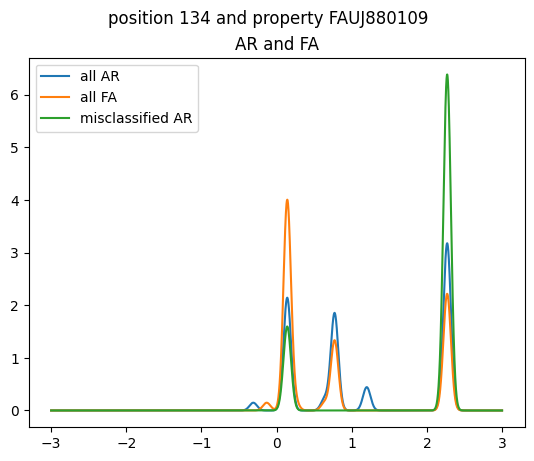

In [97]:
'''
WOLS870101
WOLS870102
WOLS870103
FAUJ880109
GRAR740102
RADA880108
ZIMJ680103
TSAJ990101
CHOP780201
CHOP780202
CHOP780203
ZIMJ680104
NEU1
NEU2
NEU3
'''

POSITION = 123
PROPERTY = 'FAUJ880109'
BANDWIDTH = 0.05

df2 = pd.DataFrame(binned_data_seqs)
df2['category_simple'] = df2['category'].apply(lambda x:x[-2:])
analysis_df = df2.copy()
for pos in range(0,979):
    analysis_df[str(pos)] = df2['aligned_seq'].apply(lambda x:x[pos])
    analysis_df[str(pos)] = df2['aligned_seq'].apply(lambda x:aa_properties_ref[x[pos]][PROPERTY])
    analysis_df = analysis_df.copy()

analysis_df_ar = analysis_df[analysis_df['category_simple'] == 'AR']
analysis_df_fa = analysis_df[analysis_df['category_simple'] == 'FA']

kdear = KernelDensity(kernel='gaussian', bandwidth=BANDWIDTH).fit(np.array(analysis_df_ar[str(POSITION)]).reshape(-1,1))
kdefa = KernelDensity(kernel='gaussian', bandwidth=BANDWIDTH).fit(np.array(analysis_df_fa[str(POSITION)]).reshape(-1,1))

arshape = kdear.score_samples(np.linspace(-3,3,6000).reshape(-1,1))
fashape = kdefa.score_samples(np.linspace(-3,3,6000).reshape(-1,1))

exp_fashape = []
for i in fashape:
    exp_fashape.append(np.exp(i))

exp_arshape = []
for i in arshape:
    exp_arshape.append(np.exp(i))

# misclassified plots

manalysis_df = analysis_df[analysis_df['misclassified'] == 'T'].copy()
analysis_df_mar = manalysis_df[manalysis_df['category_simple'] == 'AR']
analysis_df_mfa = manalysis_df[manalysis_df['category_simple'] == 'FA']
kdemar = KernelDensity(kernel='gaussian', bandwidth=BANDWIDTH).fit(np.array(analysis_df_mar[str(POSITION)]).reshape(-1,1))
kdemfa = KernelDensity(kernel='gaussian', bandwidth=BANDWIDTH).fit(np.array(analysis_df_mfa[str(POSITION)]).reshape(-1,1))
marshape = kdemar.score_samples(np.linspace(-3,3,6000).reshape(-1,1))
mfashape = kdemfa.score_samples(np.linspace(-3,3,6000).reshape(-1,1))
exp_mfashape = []
for i in mfashape:
    exp_mfashape.append(np.exp(i))

exp_marshape = []
for i in marshape:
    exp_marshape.append(np.exp(i))


import matplotlib.pyplot as plt
plt.suptitle('position ' + str(POSITION) + ' and property ' + PROPERTY)
plt.title('AR and FA')
plt.plot(np.linspace(-3,3,6000), exp_fashape, label = 'all AR')
plt.plot(np.linspace(-3,3,6000), exp_arshape, label = 'all FA')
plt.plot(np.linspace(-3,3,6000), exp_mfashape, label = 'misclassified AR')
#plt.plot(np.linspace(-3,3,6000), exp_marshape, label = 'misclassified FA')
plt.legend()
#print(exp_fashape)


### Generate KDE table

#### Regular Datapoints

In [3]:
with open('kde_tables/kde_0.25_AR-FA.csv', 'w') as f:
    for i in range(0,979):
        f.write(',' + str(i))
    f.write('\n')


    for prop in aa_properties_ref['A']:
        print(prop)
        f.write(prop)
        analysis_df = df2.copy()
        for pos in range(0,979):
            analysis_df[str(pos)] = df2['aligned_seq'].apply(lambda x:x[pos])
            analysis_df[str(pos)] = df2['aligned_seq'].apply(lambda x:aa_properties_ref[x[pos]][prop])
            analysis_df = analysis_df.copy()

        analysis_df_ar = analysis_df[analysis_df['category_simple'] == 'AR']
        analysis_df_fa = analysis_df[(analysis_df['category_simple'] == 'FA') | (analysis_df['misclassified'] == 'T')]

        for pos in range(0,979):
            kdear = KernelDensity(kernel='gaussian', bandwidth=0.25).fit(np.array(analysis_df_ar[str(pos)]).reshape(-1,1))
            kdefa = KernelDensity(kernel='gaussian', bandwidth=0.25).fit(np.array(analysis_df_fa[str(pos)]).reshape(-1,1))

            arshape = kdear.score_samples(np.linspace(-3,3,6000).reshape(-1,1))
            fashape = kdefa.score_samples(np.linspace(-3,3,6000).reshape(-1,1))

            ar_sum = 0
            fa_sum = 0
            diff_sum = 0
            for i in range(0,len(arshape)):
                #print(np.exp(arshape[i]))
                ar_sum += np.exp(arshape[i])
                fa_sum += np.exp(fashape[i])
                #if pos == 123:
                #    print(np.exp(fashape[i]))
                diff_sum += abs(np.exp(arshape[i]) - np.exp(fashape[i]))
            #print(ar_sum, fa_sum, diff_sum)
            
            f.write(',' + str(diff_sum/1000))
        f.write('\n')

    

WOLS870101
WOLS870102
WOLS870103
FAUJ880109
GRAR740102
RADA880108
ZIMJ680103
TSAJ990101
CHOP780201
CHOP780202
CHOP780203
ZIMJ680104
NEU1
NEU2
NEU3


#### Misclassified Datapoints

In [60]:
with open('kde_tables/kde_0.25_AR-mAR.csv', 'w') as f:
    for i in range(0,979):
        f.write(',' + str(i))
    f.write('\n')


    for prop in aa_properties_ref['A']:
        print(prop)
        f.write(prop)
        analysis_df = df2.copy()
        for pos in range(0,979):
            analysis_df[str(pos)] = df2['aligned_seq'].apply(lambda x:x[pos])
            analysis_df[str(pos)] = df2['aligned_seq'].apply(lambda x:aa_properties_ref[x[pos]][prop])
            analysis_df = analysis_df.copy()

        manalysis_df = analysis_df[analysis_df['misclassified'] == 'T'].copy()
        analysis_df_ar = analysis_df[analysis_df['category_simple'] == 'AR']
        analysis_df_fa = manalysis_df[manalysis_df['category_simple'] == 'AR']

        for pos in range(0,979):
            kdear = KernelDensity(kernel='gaussian', bandwidth=0.25).fit(np.array(analysis_df_ar[str(pos)]).reshape(-1,1))
            kdefa = KernelDensity(kernel='gaussian', bandwidth=0.25).fit(np.array(analysis_df_fa[str(pos)]).reshape(-1,1))

            arshape = kdear.score_samples(np.linspace(-3,3,6000).reshape(-1,1))
            fashape = kdefa.score_samples(np.linspace(-3,3,6000).reshape(-1,1))

            ar_sum = 0
            fa_sum = 0
            diff_sum = 0
            for i in range(0,len(arshape)):
                #print(np.exp(arshape[i]))
                ar_sum += np.exp(arshape[i])
                fa_sum += np.exp(fashape[i])
                #if pos == 123:
                #    print(np.exp(fashape[i]))
                diff_sum += abs(np.exp(arshape[i]) - np.exp(fashape[i]))
            #print(ar_sum, fa_sum, diff_sum)
            
            f.write(',' + str(diff_sum/1000))
        f.write('\n')

    

WOLS870101
WOLS870102
WOLS870103
FAUJ880109
GRAR740102
RADA880108
ZIMJ680103
TSAJ990101
CHOP780201
CHOP780202
CHOP780203
ZIMJ680104
NEU1
NEU2
NEU3
